In [26]:
import torch, numpy as np
from botorch.test_functions.multi_fidelity import AugmentedHartmann, AugmentedBranin
from botorch.models.cost import AffineFidelityCostModel
#, BoreholeMultiFidelity, WingWeightMultiFidelity
from botorch.models.gp_regression_fidelity import SingleTaskMultiFidelityGP
from botorch.models.transforms.outcome import Standardize
from botorch.models.transforms.input import Normalize
from botorch.exceptions.errors import ModelFittingError
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from botorch.acquisition.utils import project_to_target_fidelity
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.acquisition.analytic import LogExpectedImprovement
from botorch.optim import optimize_acqf
from torch.distributions.normal import Normal
from botorch import fit_gpytorch_mll
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
from botorch.acquisition import PosteriorMean
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
from linear_operator.settings import cholesky_jitter
from gpytorch.constraints import GreaterThan
import warnings
warnings.filterwarnings('ignore')
from botorch.acquisition.acquisition import AcquisitionFunction
from botorch.acquisition.analytic import AnalyticAcquisitionFunction
from torch.distributions.normal import Normal
import torch
from typing import Callable
from __future__ import annotations
from botorch.utils.transforms import t_batch_mode_transform
import time
import gpytorch
import matplotlib.pyplot as plt

tkwargs = {"dtype": torch.double, "device": "cpu"}
device = torch.device("cpu")
dtype = torch.double

In [2]:
def draw_initial(
    f,
    n: int = 20,
    flag_two_fid: bool = False,
):
    """
    Generate an initial design with *continuous* fidelities.

    flag_two_fid = False  -> layout [x_part , s]
    flag_two_fid = True   -> layout [x_part , s1 , s2]

    Assumes:
      - f.dim is the total input dimension
      - The last 1 (or 2) dimensions of f.bounds are fidelity dims.
    """

    # number of pure design dimensions
    dim_x = f.dim - (2 if flag_two_fid else 1)
    bounds = f.bounds.clone().to(dtype=dtype, device=device)

    # ------------------------------------------------------------------#
    # 1) sample design variables x in their physical bounds
    # ------------------------------------------------------------------#
    low_x  = bounds[0, :dim_x]        # (dim_x,)
    high_x = bounds[1, :dim_x]        # (dim_x,)

    u_x    = torch.rand(n, dim_x, dtype=torch.double, device=device)
    x_part = low_x + (high_x - low_x) * u_x      # (n , dim_x)

    # ------------------------------------------------------------------#
    # 2) sample continuous fidelity variable(s) from their bounds
    # ------------------------------------------------------------------#
    n_fid   = 2 if flag_two_fid else 1
    low_s   = bounds[0, dim_x: dim_x + n_fid]    # (n_fid,)
    high_s  = bounds[1, dim_x: dim_x + n_fid]    # (n_fid,)

    u_s     = torch.rand(n, n_fid, dtype=torch.double, device=device)
    s_part  = low_s + (high_s - low_s) * u_s     # (n, n_fid)

    # ------------------------------------------------------------------#
    # 2b) Force a proportion of initial points to be at highest fidelity
    # ------------------------------------------------------------------#
    # Choose how many high-fidelity points you want in the initial design.
    # Here: 20% of n (at least 1), change 0.20 to whatever proportion you want.
    hf_prop = 0.20
    n_hf = max(1, int(round(hf_prop * n)))

    # Randomly pick which rows become high-fidelity
    idx = torch.randperm(n, device=device)[:n_hf]

    # Set all fidelity dims to 1.0 for those rows
    s_part[idx, :] = 1.0

    # ------------------------------------------------------------------#
    # 3) build the full X matrix
    # ------------------------------------------------------------------#
    X0 = torch.cat([x_part, s_part], dim=-1)      # (n , dim_x + n_fid)

    Y0 = f(X0).unsqueeze(-1)
    return X0, Y0


In [3]:
def fit_mf_gp(X: torch.Tensor, Y: torch.Tensor, fid_dims) -> SingleTaskMultiFidelityGP:
    # Allow passing a single int or a list of ints
    if isinstance(fid_dims, int):
        fid_dims = [fid_dims]

    model = SingleTaskMultiFidelityGP(
        train_X=X,
        train_Y=Y,
        data_fidelities=fid_dims,
        linear_truncated=True,
        outcome_transform=Standardize(m=1),
    ).to(dtype=torch.double, device=device)

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model



In [4]:
class MFEI(AnalyticAcquisitionFunction):
    """
    Cost-aware multi-fidelity EI for q=1 and continuous fidelities.

    For a candidate X (shape: batch x 1 x d) with x in first dim_x dims
    and fidelity dims in the last one or two dims, the stage value is:

        EI_hi(x) * ρ((x,s), (x,s_hi)) * sqrt( cost(s_hi) / cost(s) )

    where:
      - EI_hi(x) is analytic EI at the *high* fidelity s_hi
      - ρ is the posterior correlation between (x,s) and (x,s_hi)
      - cost(·) is given by an AffineFidelityCostModel
    """

    def __init__(
        self,
        model,
        dim_x: int,
        s_hi: float,
        cost_model: AffineFidelityCostModel,
        best_f: float,
        eps: float = 1e-9,
        posterior_transform=None,
        debug: bool = False,
        max_debug_calls: int = 6,
        **kwargs,
    ):
        super().__init__(model=model, posterior_transform=posterior_transform)
        self.dim_x        = int(dim_x)
        self.s_hi         = float(s_hi)
        self.cost_model   = cost_model
        self.best_f       = float(best_f)
        self.eps          = eps
        self._dbg         = debug
        self._dbg_count   = 0
        self._dbg_limit   = int(max_debug_calls)

        # standard normal for EI formula
        self._std_normal = Normal(
            torch.zeros(
                1,
                dtype=model.train_targets.dtype,
                device=model.train_targets.device,
            ),
            torch.ones(
                1,
                dtype=model.train_targets.dtype,
                device=model.train_targets.device,
            ),
        )

    def _stats(self, name: str, t: torch.Tensor):
        """Print shape + basic stats – robust to empty tensors."""
        if not self._dbg:
            return
        s = f"{name:10}  shape={tuple(t.shape)}"
        if t.numel() == 0:
            print(s + "  EMPTY")
            return
        with torch.no_grad():
            s += (
                f"  min={float(t.min()):.3e}  max={float(t.max()):.3e}  "
                f"nan={(~torch.isfinite(t)).sum().item()}  "
                f"inf={(torch.isinf(t)).sum().item()})"
            )
        print(s)

    @t_batch_mode_transform(expected_q=1)
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        X: batch_shape x 1 x d
        """
        if self._dbg:
            print(f"\n==== forward call {self._dbg_count} ====")
            self._dbg_count += 1
            self._stats("X in", X)


        # Extract single point per batch: (..., d)

        X0 = X[..., 0, :]
        d_total = X0.shape[-1]
        dim_x = self.dim_x

        # Split into design and fidelity parts
        xd = X0[..., :dim_x]                # (..., dim_x)
        s  = X0[..., dim_x:]                # (..., n_fid)  with n_fid = d_total - dim_x

        # Build high-fidelity point (same x, all fidelities = s_hi)
        s_hi = torch.full_like(s, self.s_hi)
        X_hi0 = torch.cat([xd, s_hi], dim=-1)   # (..., d_total)
        X_s0  = X0                              # (..., d_total)

        # Stack (x, s) and (x, s_hi) for joint posterior
        X_pair = torch.stack([X_s0, X_hi0], dim=-2)   # (..., 2, d_total)
        self._stats("X_pair", X_pair)


        # Posterior for both fidelities at once

        with gpytorch.settings.fast_pred_var(True):
            post_pair = self.model.posterior(
                X_pair,
                posterior_transform=self.posterior_transform,
                observation_noise=False,
            )


        # Means / variances

        mean2 = post_pair.mean.squeeze(-1)                     # (..., 2)
        mu_hi = mean2[..., 1]

        var2  = post_pair.variance.squeeze(-1).clamp_min(self.eps)  # (..., 2)
        var_ss, var_hh = var2[..., 0], var2[..., 1]

        # Off-diagonal covariance Cov[(x,s), (x,s_hi)]
        mvn = post_pair.mvn
        cov_sh = mvn.covariance_matrix[..., 0, 1]              # (...,)

        # Correlation ρ
        rho = (cov_sh / (var_ss.sqrt() * var_hh.sqrt())).clamp(-1.0, 1.0)
        self._stats("rho", rho)


        # Analytic EI at high fidelity using mu_hi, var_hh

        sigma = var_hh.sqrt()
        z     = (mu_hi - self.best_f) / sigma
        cdf_z = self._std_normal.cdf(z)
        log_pdf_z = self._std_normal.log_prob(z)
        ei    = (mu_hi - self.best_f) * cdf_z + sigma * torch.exp(log_pdf_z)
        self._stats("EI", ei)


        # Cost ratio: cost(x, s_hi) / cost(x, s)
        # cost_model expects shape (..., q, d), so give q=1

        cost_hi = self.cost_model(X_hi0.unsqueeze(-2)).squeeze(-1).squeeze(-1)
        cost_s  = self.cost_model(X).squeeze(-1).squeeze(-1)
        cost_ratio = cost_hi / cost_s
        self._stats("cost ratio", cost_ratio)


        # Final value
        val = ei * rho * (cost_ratio)
        self._stats("val", val)

        return val


In [56]:
from botorch.acquisition import PosteriorMean
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
def run_cost_aware_mfei_bo_once(
    f: Callable,
    T: int = 30,
    init_n: int = 16,
    s_hi: float = 1.0,
    cost_dict: dict | None = None,   # now a config for affine cost: {"fixed_cost": ..., "w": ...} or {"fixed_cost": ..., "w1": ..., "w2": ...}
    seed: int | None = None,
    per_run_plots: bool = True,
    flag_two_fid: bool = False,
):
    """
    One cost-aware multi-fidelity EI run with continuous fidelities.

    Returns dict with keys:
        cum_cost, best_hi
    """
    if seed is not None:
        torch.manual_seed(int(seed))
        np.random.seed(int(seed))

    # ---------------------------------------------------------------
    # Dimensions & fidelity indices
    # ---------------------------------------------------------------
    if flag_two_fid:
        dim_x   = f.dim - 2
        d_total = f.dim
        fid_dims = [f.dim - 2, f.dim - 1]   # last two dims are fidelities
    else:
        dim_x   = f.dim - 1
        d_total = f.dim
        fid_dims = [f.dim - 1]              # last dim is fidelity

    bounds = f.bounds.clone().detach().to(**tkwargs)

    # ---------------------------------------------------------------
    # Affine cost model: cost = fixed_cost + Σ w_j * s_j
    # (s_j are the fidelity coordinates)
    # ---------------------------------------------------------------
    if cost_dict is None:
        # reasonable default
        cost_dict = {"fixed_cost": 1.0, "w": 1.0}

    fixed_cost = float(cost_dict.get("fixed_cost", 1.0))
    if len(fid_dims) == 1:
        w = float(cost_dict.get("w", 1.0))
        fidelity_weights = {fid_dims[0]: w}
    else:
        w1 = float(cost_dict.get("w1", 1.0))
        w2 = float(cost_dict.get("w2", 1.0))
        fidelity_weights = {
            fid_dims[0]: w1,
            fid_dims[1]: w2,
        }

    cost_model = AffineFidelityCostModel(
        fidelity_weights=fidelity_weights,
        fixed_cost=fixed_cost,
    )

    # ---------------------------------------------------------------
    # Initial design & initial GP
    # ---------------------------------------------------------------
    X, Y = draw_initial(f, init_n, flag_two_fid=flag_two_fid)
    print(f"X values are : {X.tolist()}")
    print(f"Y values are : {Y.squeeze(-1).tolist()}")    

    iter_idx, cum_cost_hist, best_hi_hist = [], [], []

    model = fit_mf_gp(X, Y, fid_dims)
    total_cost = 0.0
    prev_best = float("-inf")
    current_best = prev_best
    t = 0
    # ---------------------------------------------------------------
    # BO loop
    # ---------------------------------------------------------------
    iters_since_hf = 0  # number of consecutive BO iters without an HF eval
    for t in range(T): 
        # Re-fit model each iteration (optional; we already fit above)
        model = fit_mf_gp(X, Y, fid_dims)

        # Current best at high fidelity s_hi in *all* fidelity dims
        tol = 1e-2
        hf_mask = torch.ones(X.shape[0], dtype=torch.bool, device=X.device)
        for d in fid_dims:
            hf_mask &= torch.isclose(
                X[:, d],
                torch.as_tensor(s_hi, dtype=X.dtype, device=X.device),
                atol=tol, rtol=0.0,
            )



        y_max = Y[hf_mask].max()


        best_f_value = float(y_max.item())

        # -----------------------------------------------------------
        # Every 5 iterations: ensure at least one evaluation at s_hi
        # in the most recent 5 BO samples (new_x's).
        # If none, force this iteration to evaluate at s_hi.
        # -----------------------------------------------------------
        # force_hf = ((t + 1) % 5 == 0) and (iters_since_hf >= 4)
        hf_exploit = ((t + 1) % 5 == 0) and (iters_since_hf >= 4)
        if (t + 1) % 5 == 0:
            # look at the last up-to-5 evaluated points so far
            last_k = min(5, X.shape[0])
            X_recent = X[-last_k:]

            tol_hf = 1e-2
            recent_hf_mask = torch.ones(X_recent.shape[0], dtype=torch.bool, device=X.device)
            for d in fid_dims:
                recent_hf_mask &= torch.isclose(
                    X_recent[:, d],
                    torch.as_tensor(s_hi, dtype=X.dtype, device=X.device),
                    atol=tol_hf, rtol=0.0,
                )

            if not recent_hf_mask.any():
                hf_exploit = True


        if hf_exploit:
            hf_logei = LogExpectedImprovement(
                model=model,
                best_f=best_f_value,
            )
            fixed_features = {d: float(s_hi) for d in fid_dims}

            new_x, _ = optimize_acqf(
                acq_function=hf_logei,
                bounds=bounds,
                q=1,
                num_restarts=12,
                raw_samples=512,
                fixed_features=fixed_features,
                options={"batch_limit": 5, "maxiter": 200},
            )

        else:
            # -------------------------------------------------------
            # Regular step: maximize cost-aware MFEI (fidelity free)
            # -------------------------------------------------------
            acqf = MFEI(
                model=model,
                dim_x=dim_x,
                s_hi=s_hi,
                cost_model=cost_model,
                best_f=best_f_value,
                debug=False,
            )

            new_x, _ = optimize_acqf(
                acq_function=acqf,
                bounds=bounds,
                q=1,
                num_restarts=12,
                raw_samples=256,
                options={"batch_limit": 5, "maxiter": 200},
            )

        # If we must sample high fidelity on this iteration, overwrite fidelity dim(s)
        # if force_hf:
        if hf_exploit:
            new_x = new_x.clone()
            for d in fid_dims:
                new_x[0, d] = torch.as_tensor(s_hi, dtype=new_x.dtype, device=new_x.device)
                
        # Update HF counter
        tol_hf = 1e-2
        is_hf = True
        for d in fid_dims:
            is_hf = is_hf and torch.isclose(
                new_x[0, d],
                torch.as_tensor(s_hi, dtype=new_x.dtype, device=new_x.device),
                atol=tol_hf, rtol=0.0,
            ).item()

        iters_since_hf = 0 if is_hf else (iters_since_hf + 1)
                
        new_y = f(new_x).view(1, 1)

        # Cost of this evaluation via affine cost model
        cost_t = cost_model(new_x).squeeze(-1).squeeze(-1).item()
        total_cost += cost_t

        cum_cost_hist.append(total_cost)
        iter_idx.append(t + 1)

        X = torch.cat([X, new_x], dim=0)
        Y = torch.cat([Y, new_y], dim=0)

        # Update best high-fidelity value
        tol = 1e-2
        hf_mask = torch.ones(X.shape[0], dtype=torch.bool, device=X.device)
        for d in fid_dims:
            hf_mask &= torch.isclose(
                X[:, d],
                torch.as_tensor(s_hi, dtype=X.dtype, device=X.device),
                atol=tol, rtol=0.0,
            )

        if hf_mask.any():
            prev_best = Y[hf_mask].max().item()
        current_best = prev_best
        best_hi_hist.append(current_best)

        # Progress print
        if t % 1 == 0 or t == T - 1:
            s_vals = X[-1, fid_dims].tolist()
            s_str = ", ".join(f"{sv:.3f}" for sv in s_vals)
            print(
                f"Iter {t+1:02d} | s=[{s_str}] | y={new_y.item():.6f} "
                f"| cost={cost_t:.6f} | cum_cost={total_cost:.6f} "
                f"| best_hf={current_best:.6f}"
            )
    
    # ---------------------------------------------------------------
    # Plots
    # ---------------------------------------------------------------
    if per_run_plots:
        plt.figure()
        plt.plot(cum_cost_hist, best_hi_hist, linewidth=1)
        plt.xlabel("Cumulative cost")
        plt.ylabel(f"Best observed @ s≈{s_hi}")
        plt.title("Best high fidelity vs cumulative cost")
        plt.grid(True)
        plt.show()

    # ---------------------------------------------------------------
    # Return results
    # ---------------------------------------------------------------
    return {
        "cum_cost": cum_cost_hist,
        "best_hi":  best_hi_hist,
    }


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tests import AugmentedBukin, AugmentedRastrigin, AugmentedAckley
from tests import SuzukiMFEmulator

def run_single(f, seed: int, total_iters: int = 35):
    """Run a single BO experiment and return a DataFrame of its trajectory.

    Assumes continuous fidelity variable(s) and that run_cost_aware_mfei_bo_once
    interprets cost_dict as:
      - one fidelity dim:  {"fixed_cost": c0, "w": w}
            cost(s) = c0 + w * s
      - two fidelity dims: {"fixed_cost": c0, "w1": w1, "w2": w2}
            cost(s1, s2) = c0 + w1 * s1 + w2 * s2
    """

    # -------------------------------------------------------
    # pick defaults based on the *type* of f
    # -------------------------------------------------------
    if isinstance(f, AugmentedHartmann):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False     # 1 fidelity dim (last column)
        s_hi        = 1.0        # high fidelity at s = 1

    elif isinstance(f, AugmentedBranin):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    elif isinstance(f, (AugmentedBukin, AugmentedRastrigin, AugmentedAckley)):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    # elif isinstance(f, AugmentedRosenbrock):
    #     cost_dict   = {"fixed_cost": 5.0, "w1": 1.0, "w2": 1.0}
    #     flag_two_fid = True      # 2 fidelity dims (last two columns)
    #     s_hi        = 1.0        # high fidelity at (1,1)

    elif isinstance(f, SuzukiMFEmulator):
        cost_dict    = {"fixed_cost": 5.0, "w": 1.0}  # cost increases with fidelity
        flag_two_fid = False
        s_hi         = 1.0



    else:
        raise ValueError(
            "Unknown function"
        )

    # -------------------------------------------------------
    # run the BO loop with those settings
    # -------------------------------------------------------
    results = run_cost_aware_mfei_bo_once(
        f=f,
        T=total_iters,
        init_n=32,
        s_hi=s_hi,
        cost_dict=cost_dict,
        seed=seed,
        per_run_plots=True,
        flag_two_fid=flag_two_fid,
    )

    df = pd.DataFrame({
        "iteration":       np.arange(1, len(results["cum_cost"]) + 1),
        "cumulative_cost": results["cum_cost"],
        "best_hi":         results["best_hi"],
    })
    return df



def aggregate_runs(dfs):
    """Stack per-run dataframes and compute mean & std."""
    merged = (
        pd.concat(
            {i: df.set_index("iteration") for i, df in enumerate(dfs)},
            names=["run", "iteration"],
        )
        .reset_index(level="run")
    )
    stats = (
        merged.groupby("iteration")
        .agg(["mean", "std"])  # adds a 2-level column index
    )
    # Flatten multi-index columns: e.g. ('cumulative_cost','mean') → 'cumulative_cost_mean'
    stats.columns = [f"{col}_{stat}" for col, stat in stats.columns]
    return stats.reset_index()

def plot_with_band(iterations, mean, std, ylabel, title):
    plt.figure()
    # plt.ylim(3.251, 3.291)
    plt.plot(iterations, mean, lw=2, label="mean")
    plt.fill_between(iterations, mean - std, mean + std, alpha=0.25, label="±1 σ")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

def plot_best_vs_cost(cost_mean, cost_std, best_mean, best_std,
                      title="Best observed vs. cumulative cost (mean ± 1 σ)",
                      optimum_val=None):
    """
    Scatter-line plot of mean best-observed value vs mean cumulative cost,
    with a shaded ±1 σ region around the best value.
    """
    # sort by cost so the line is monotone
    order = np.argsort(cost_mean)
    cost_mean, best_mean = cost_mean.iloc[order], best_mean.iloc[order]
    best_std            = best_std.iloc[order]

    plt.figure()
    plt.plot(cost_mean, best_mean, lw=2, label="mean trajectory")
    plt.fill_between(cost_mean,
                     best_mean - best_std,
                     best_mean + best_std,
                     alpha=0.25,
                     label="±1 σ (best)")
    if optimum_val is not None:
        plt.axhline(optimum_val, ls="--", label=f"True optimum = {optimum_val}")

    plt.xlabel("Cumulative cost (mean)")
    plt.ylabel("Best observed hi-fidelity value (mean)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()



=== Running ackley (iters=57) ===
X values are : [[29.408646552580457, 3.2547709150356354, 6.99659127160308, 1.0], [-26.62221531431235, 4.611210966363991, 30.262612904886815, 0.12653471480029077], [-15.296098423064382, -15.718566255854189, 4.1450320866169434, 1.0], [2.128994293385503, -8.196180578949111, 11.836405092823398, 0.17529624502097463], [28.43670197890571, 11.954503348483541, -24.58878919479817, 0.044979442777552836], [1.6805301297611166, 1.7387530667239943, 22.412599304203113, 0.8029731801645625], [-21.98570738980102, -16.717380286492357, -9.45166331271406, 0.41186848982015034], [-4.62377476398494, -3.0574607614595735, 15.412106929631754, 0.10950294491161194], [-32.176638722917836, -10.884215002436001, 13.845003757096244, 0.49486487986044625], [-22.808596436765598, 22.984801953064846, 13.05157231933552, 0.4148507871994588], [-22.718323909249435, 4.86574900169073, -4.9421038848180245, 0.45293066133258275], [23.877953881923467, 29.85447014527049, 23.203046187098685, 0.73935412

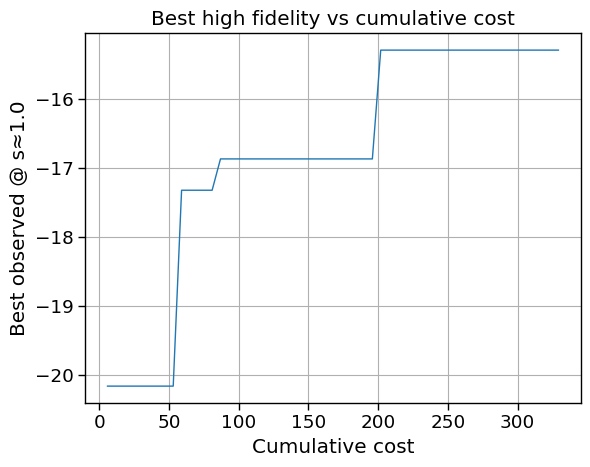

X values are : [[-28.956787608031746, -28.645119267662885, -24.66866313465633, 0.5568278840364884], [-29.322106348432456, 1.7152014322736733, -1.521434375783734, 0.6040106348470814], [29.83432685152775, 28.098729178394102, -27.292901785412056, 0.05836936919045799], [-24.075260909735213, -22.475341987138236, -8.167946187538394, 0.9616452225299865], [22.44737307977232, 24.281156274336396, -8.02600024338862, 0.36697335041217716], [7.368644296297106, -26.993637135838675, 13.18465647082214, 0.3685181023455737], [8.087344470700891, -4.11048360079182, -27.87017500434445, 1.0], [12.021282708302131, -12.305125820139924, -12.513523975895616, 0.5527800061779405], [-30.714090918548894, -30.122543175437045, 28.30557445193719, 0.6961503693253772], [-22.79828177403482, -15.398016663659423, -24.2199106268624, 0.5504868528448952], [-16.262416240389417, -17.47136092189833, -17.97881208547006, 0.46422411911062667], [-11.955876806195185, 7.497861352756715, 6.407543294265814, 0.36873350289403417], [22.8722

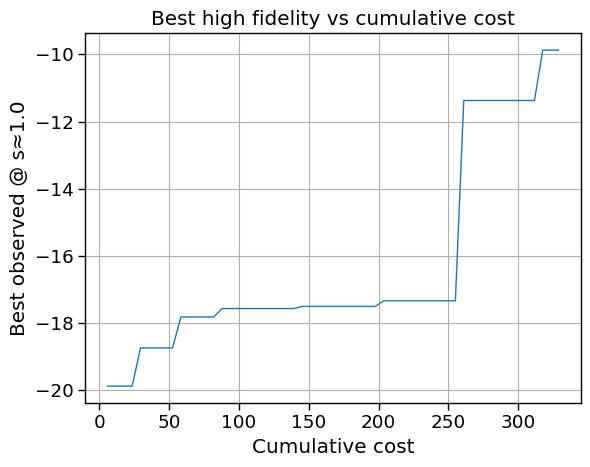

X values are : [[-20.67323099441617, 9.342497120875294, -29.94066711194147, 1.0], [6.0351788194891824, 5.37103848140768, 24.93416031650905, 0.27680219749944457], [-25.624160890509025, -10.862907238576788, 14.186349046043148, 1.0], [7.298238152366785, -29.07721289408202, -16.62677194269882, 0.7909847293189153], [-22.23966664831464, -18.99508448501015, 3.403099807806875, 0.9856853169640366], [16.99206190311618, -5.248062132058376, 3.502442127019954, 1.0], [19.718455400190393, 21.715189736205268, 7.773024373984001, 0.5109384366055939], [-23.904258990089257, -30.8399008691516, 30.63094835216244, 0.8985362271176962], [18.228415156938908, -15.688332554433153, 3.1221196274602434, 0.932986738366961], [32.61673899155352, -12.064143723947556, 24.74929392650371, 1.0], [24.207611763567634, -8.428542244768732, 20.08599947081943, 0.5445649154768258], [10.188666164822152, -3.205478532149179, 7.871135451458393, 0.8884283379909195], [-15.542936096095865, 25.305067756362, 9.40668555373194, 0.08543667773

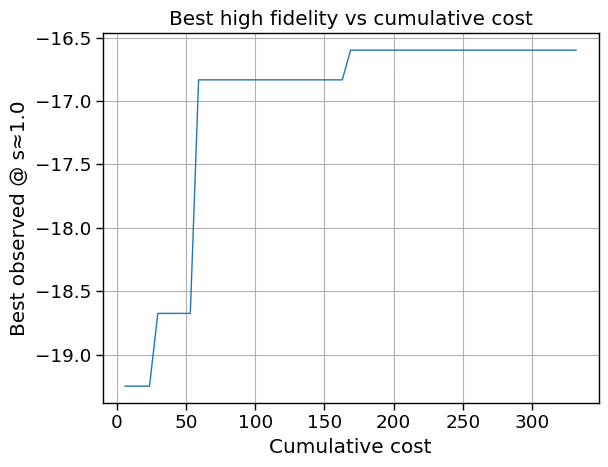

X values are : [[-0.04198974170823533, -31.39928593015618, 30.18314529829309, 0.19750445790101612], [-3.4979713738222777, 32.165522950618794, -4.1785828382223755, 1.0], [27.34221065404487, 6.438299525563814, 25.256482048822782, 0.9541877924517747], [10.023811803141747, 20.576875843290466, 13.20987404332142, 0.45939060548073585], [0.04296626278167537, 17.43892151936071, 19.4849346191142, 1.0], [-20.27130974235181, 25.920634056171473, 6.883080712778948, 0.42843648486553376], [-18.306076292897814, 3.731655071340626, 29.508537739290013, 0.10460563667598599], [8.894736496432841, 22.29227354828761, -16.94216884637988, 0.41116949998238195], [-10.046397961037982, 26.472249366409592, -19.7222890237788, 0.9560688877416299], [-11.37592930008968, 16.474189883286996, -24.551986113018224, 0.028688998843026114], [0.6154661140715874, -3.936065825269587, -30.870117180680406, 0.21104617676571003], [3.5023324327505847, -26.56124546091749, 6.3828042636408, 0.050797977371258685], [-13.504467500606175, 32.0

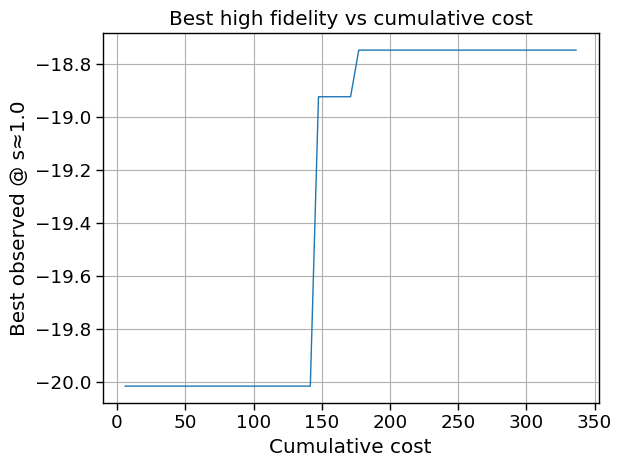

X values are : [[26.458117232000845, 28.726342229779384, 13.632238156549349, 0.21770708827448737], [-26.211692506068655, 24.625118447818025, -26.417214111441417, 0.43889586283615967], [2.0251173792278223, 17.93127871284952, -11.01888033566183, 0.35898630471813486], [-30.042296409588513, -29.843025433202804, -23.020547896341093, 0.6021547793504186], [-16.878964076978782, -14.610170941255799, 12.600611863632153, 0.7684211766252089], [-2.938218842891061, 21.841242399221535, 17.151290856777145, 0.635861767187731], [22.103662795267788, -13.296911196827729, -3.23713422401136, 0.7491828436526841], [23.462827313264235, -3.7306987653885315, 15.753146066408078, 0.3894434640243526], [19.71659957784916, -31.264669508646797, -3.23604726986731, 0.7616666303006222], [30.02194590388946, 7.4377609248088135, 15.860220506042083, 0.7727982999125868], [20.395025082550177, 26.02087439871542, -6.106753456222439, 1.0], [4.622378028509452, -8.510145874756738, -7.0531277207375105, 0.380618994501716], [6.1564075

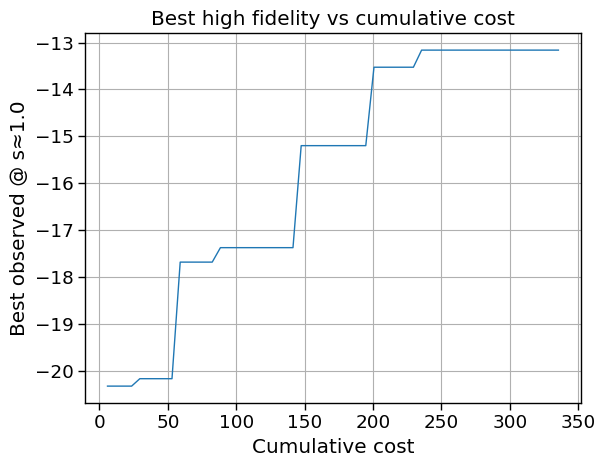

X values are : [[2.5407554430493207, -24.19306304439631, -10.83061881592073, 0.5986909925146792], [-29.96167913141785, 4.243869564111577, 26.223335362734524, 0.3569755546207566], [-22.34962506429349, 13.887219710572353, 27.126223455927835, 0.14063248174553467], [-20.81900930661866, 18.798386716400536, 13.666590851505, 0.3933244956682228], [-5.142212131434164, 19.226338107688278, 20.605222524563274, 1.0], [-28.025553979586075, 26.874775037690107, -10.098404046174167, 0.7531136044360162], [-7.831861153713849, 18.637359945623245, -7.945186385366135, 0.9195950847874662], [-13.159007161131296, -25.06935762525856, 26.79252118348448, 0.3175344734603345], [-15.845358153482945, 27.030649017148143, -27.099865126555795, 0.252511569018957], [17.708997309957965, 11.1940961143126, 23.809845297902662, 0.03722189416018995], [26.614523247789165, -23.76234910242096, 10.401739527701103, 0.10097534823088472], [12.739984748758445, -19.234887721145597, 15.73180455910574, 0.07947364015044933], [-13.901080343

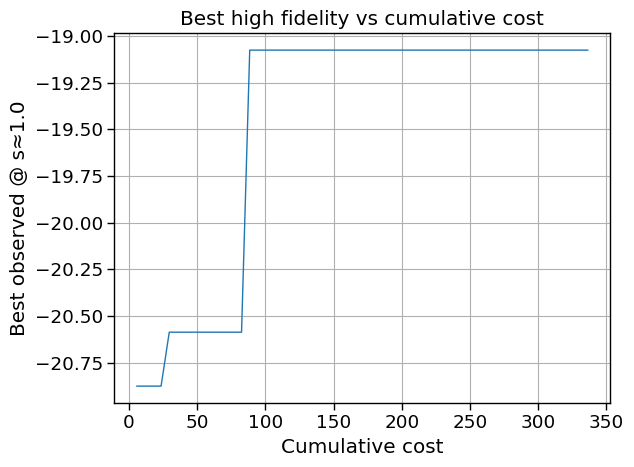

Saved aggregate stats → mf_ei_runs_cont_ackley.csv


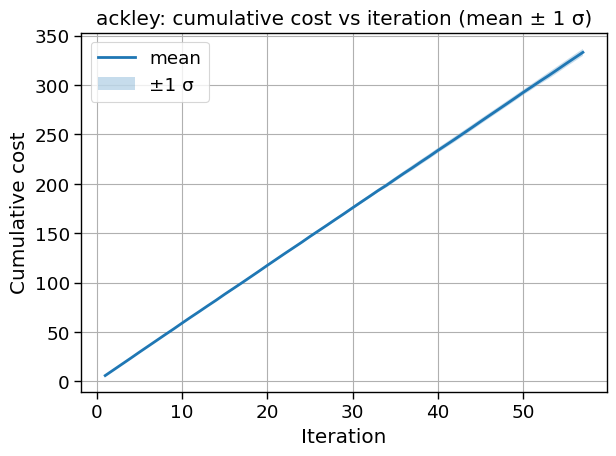

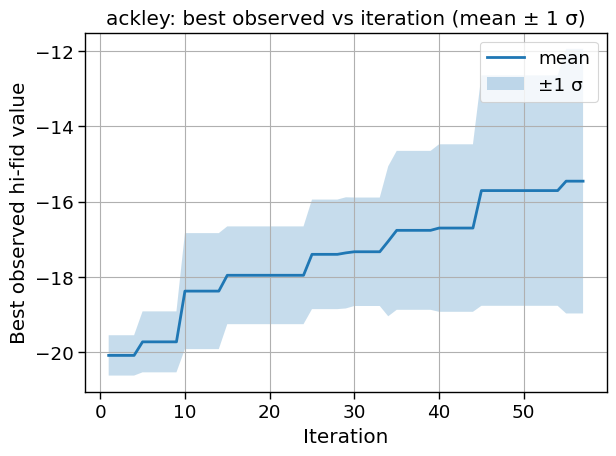

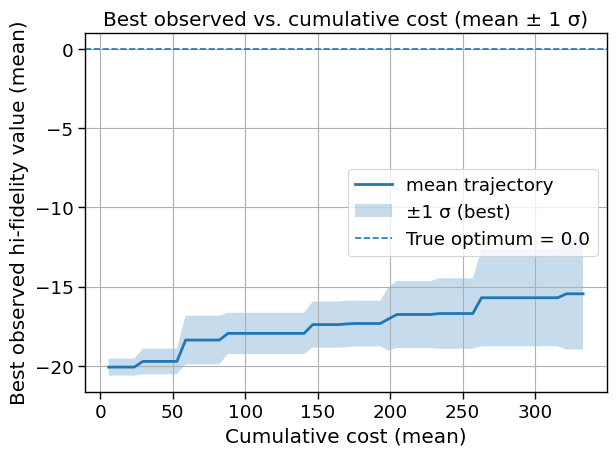

In [66]:
import matplotlib.pyplot as plt
from collections import OrderedDict


# ------------------------------------------------------------------
# 0)  Benchmarks and their custom settings
# ------------------------------------------------------------------
benchmarks = OrderedDict([
    # ("hartmann",   (AugmentedHartmann(negate=True), 60,  3.32237)),
    # ("branin",     (AugmentedBranin(negate=True), 50, -0.3978)),
    # ("bukin",      (AugmentedBukin(negate=True), 50, -0.0)),
    ("ackley",  (AugmentedAckley(dim=3, negate=True), 57,  0.0)),
    # ("rastrigin",  (AugmentedRastrigin(dim=3, negate=True), 5, -0.0)),
    # ("rosenbrock", (AugmentedRosenbrock(dim=4, negate=True), 150, -0.0)),
    # ("suzuki_mf", (SuzukiMFEmulator(num_samples=32, stochastic=True),60, None)),
])

SEEDS = [ 33, 42, 88, 105, 67, 151,]  # 6 runs each 
# ------------------------------------------------------------------

# 1)  Loop over benchmarks
# ------------------------------------------------------------------
for tag, (f, total_iters, opt_val) in benchmarks.items():
    print(f"\n=== Running {tag} (iters={total_iters}) ===")

    # 1a) independent runs
    run_dfs = [run_single(f=f, seed=s, total_iters=total_iters) for s in SEEDS]

    # 1b) aggregate & save
    stats_df = aggregate_runs(run_dfs)
    out_csv  = f"mf_ei_runs_cont_{tag}.csv"
    stats_df.to_csv(out_csv, index=False)
    print(f"Saved aggregate stats → {out_csv}")

    # 1c) plots
    iters = stats_df["iteration"]

    plot_with_band(
        iters,
        stats_df["cumulative_cost_mean"],
        stats_df["cumulative_cost_std"],
        ylabel="Cumulative cost",
        title=f"{tag}: cumulative cost vs iteration (mean ± 1 σ)",
    )

    plot_with_band(
        iters,
        stats_df["best_hi_mean"],
        stats_df["best_hi_std"],
        ylabel="Best observed hi-fid value",
        title=f"{tag}: best observed vs iteration (mean ± 1 σ)",
    )

    plot_best_vs_cost(
        cost_mean=stats_df["cumulative_cost_mean"],
        cost_std=stats_df["cumulative_cost_std"],
        best_mean=stats_df["best_hi_mean"],
        best_std=stats_df["best_hi_std"],
        optimum_val=opt_val,          # show dashed line only if not None
    )
    plt.show()
# ------------------------------------------------------------------
